# Exploratory Data Analysis

This notebook will look to inspect and understand the data and relationships in the data. The idea is to understand the input into the model we are trying to build. We will look to identify the balance of the dataset, the correlations between variables and the distribution of data in each variable so we can assess which features will be useful and also which features need work or offer no information. 
We will also produce visual representations of the data. We will be loading data from `01_raw_loaded.parquet`
This notebook depends on 01_ingest`.ipynb` having been run first to generate `01_raw_loaded.parquet`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels

sys.path.append(".")

In [2]:
import os
print(os.getcwd())

C:\Users\ashma\projects\grade-profile-ml\notebooks


In [3]:
df = pd.read_parquet(Path("../data/processed/01_raw_loaded.parquet"))

## Grade Distribution

Trying to understand the frequency distribution of grades across different cohort. Also, trying to understand whether there is an imbalance in the dataset. If 80% of grades are distinction, a model that always predicts Distinction would be 80% accurate without learning anything useful

In [4]:
#Renaming columns

GRADE_COL = "aptem__UserILRSummary_GradingOutcome"
LEVEL_COL = "Apprenticeship Level"
EPAO_COL = "EPAO"
AGE_COL = "Age Bracket"
DATE_COL = "Achievement Date (ILR)"
PROGRAMME_COL = "Current Programme (Aptem)"

In [5]:
print(f'The Distribution of grade values:')
print(df[GRADE_COL].value_counts())
print(f'\nThe % Distribution of grade values:')
print(df[GRADE_COL].value_counts(normalize=True)*100)
print(f'\nThe unique grade values:')
print(df[GRADE_COL].nunique())

The Distribution of grade values:
aptem__UserILRSummary_GradingOutcome
Distinction    138
Pass            92
Merit           88
Name: count, dtype: int64

The % Distribution of grade values:
aptem__UserILRSummary_GradingOutcome
Distinction    43.396226
Pass           28.930818
Merit          27.672956
Name: proportion, dtype: float64

The unique grade values:
3


The above results show there are 3 grade values present. The distribution shows a higher percentage of distinctions (43%) but not considerably larger than the other 2 (29% pass and 28% merit) which means there is a slight imbalance but not too drastic, however we should take this into account while creating samples or train and test sets indicating we have to use stratified sampling. 


In [6]:
df.head()

,Current Programme (Aptem),Apprenticeship Level,Achievement Date (ILR),EPAO,aptem__UserILRSummary_GradingOutcome,Age Bracket
0,L3 NHS Data Citizen Apprenticeship Standard,3,2023-03-06,AP,Pass,50+
1,L7 AI Data Specialist Delivery Programme [L7 D...,4,2023-03-07,BCS,Pass,18-29
2,L3 NHS Data Citizen Apprenticeship Standard,3,2023-03-08,AP,Pass,30-49
3,Data Technician L3 (DDJ) Apprenticeship Standard,3,2023-03-08,AIM,None,50+
4,L7 AI Data Specialist Delivery Programme [L7 D...,7,2023-03-08,BCS,Pass,30-49


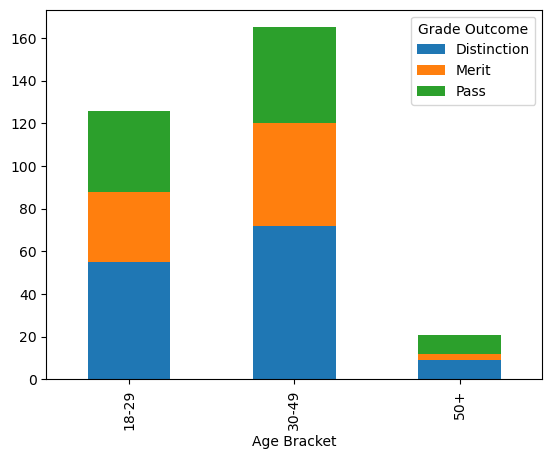

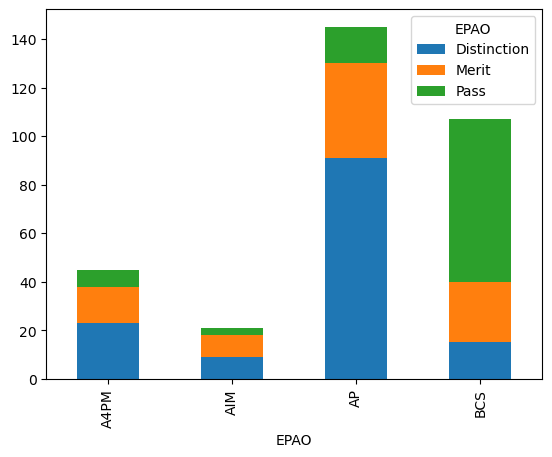

In [7]:
df_viz = pd.crosstab(index=df[AGE_COL],columns=(df[GRADE_COL]))
df_viz_1 = pd.crosstab(index=df[EPAO_COL],columns=(df[GRADE_COL]))
df_viz_2 = pd.crosstab(index=df[LEVEL_COL],columns=(df[GRADE_COL]))

fig1, ax1= plt.subplots()

df_viz.plot(kind='bar', stacked=True, ax=ax1)
ax1.legend(title='Grade Outcome')

fig2, ax2= plt.subplots()
df_viz_1.plot(kind='bar', stacked=True, ax=ax2)
ax2.legend(title='EPAO')

### Observations

Age does not seem to be a big factor in deciding grades as we see a similar proportion of students in all age categories recieving each grade leading to a conclusion that it isn't a moajor driver behind distinction attainment.
On the other hand, EPAO seems to show varying degrees of distinction attainment. This corroborates my stakeholder discussion where they did mention BCS is typically more stringent in it's marking compared to EPAOs like AP who are more holistic and considerate of student outcomes rather than being focussed on exact learning. 

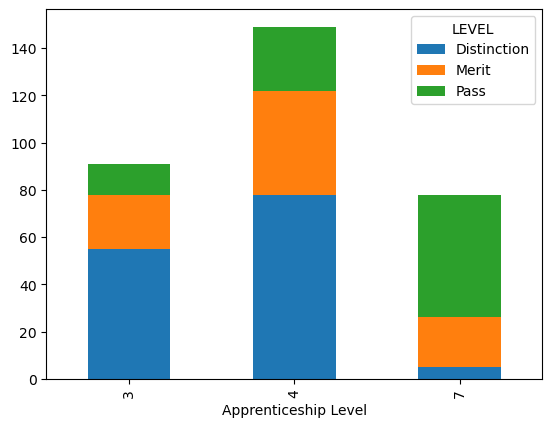

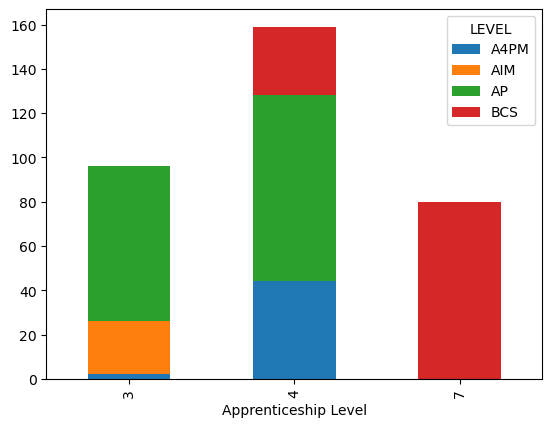

In [10]:
fig2, ax3= plt.subplots()
df_viz_2.plot(kind='bar', stacked=True, ax=ax3)
ax3.legend(title='LEVEL')

df_viz4 = pd.crosstab(df[LEVEL_COL],df[EPAO_COL])

fig, ax4 = plt.subplots()
df_viz4.plot(kind='bar', stacked=True, ax=ax4)
ax4.legend(title='LEVEL')

### Observation

After plotting EPAO against Level I have discovered that all the level 7 students were assessed by BCS indicating that may be a confounding variable in my earlier assumption that BCS was more stringent. The level 7 apprenticeships are harder and therefore tougher to achieve a distinction in. 
What this indicates is that level and EPAO cannot be treated as independent variables as there is a relationship between them, as a solution I will stratify the analysis to apply the model based on level rather than applying it to the entire dataset so every level will have a separate prediction. 

In [11]:
df.dtypes

Current Programme (Aptem)                       object
Apprenticeship Level                             int64
Achievement Date (ILR)                  datetime64[ns]
EPAO                                            object
aptem__UserILRSummary_GradingOutcome            object
Age Bracket                                     object
dtype: object

In [15]:
df['Compl_month'] = df[DATE_COL].dt.month
df['Compl_year'] = df[DATE_COL].dt.year
df['period'] = df[DATE_COL].dt.to_period('M')

In [16]:
df[['Compl_month', 'Compl_year', 'period']].head()

,Compl_month,Compl_year,period
0,3,2023,2023-03
1,3,2023,2023-03
2,3,2023,2023-03
3,3,2023,2023-03
4,3,2023,2023-03


In [19]:
monthly_completions = df.groupby('period').size().reset_index()

In [24]:
monthly_completions.columns = ['period', 'completions']
print(monthly_completions)


     period  completions
0   2023-03           21
1   2023-04           14
2   2023-05           22
3   2023-06           21
4   2023-07           61
5   2023-08           19
6   2023-09           28
7   2023-10           37
8   2023-11           18
9   2023-12           27
10  2024-01           38
11  2024-02           29


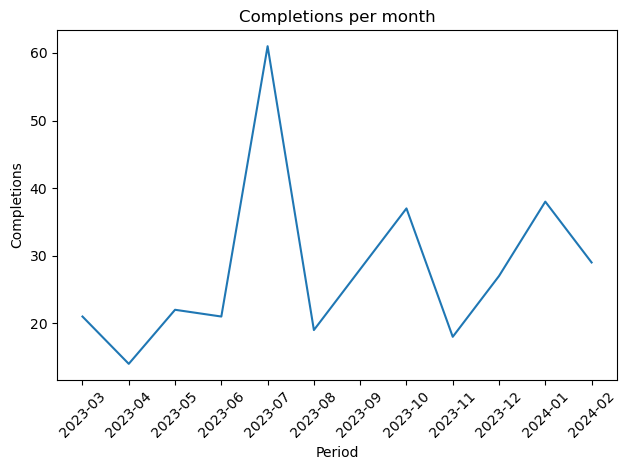

In [34]:

fig,ax = plt.subplots() 

ax.plot(monthly_completions['period'].astype('str'),monthly_completions['completions'])
plt.xticks(rotation=45)

ax.set_title('Completions per month')
ax.set_xlabel('Period')
ax.set_ylabel('Completions')
plt.tight_layout()
plt.show()


### Observations

Here we see that completion rates vary across the year with a large spike in July. As the data is limited and we cannot see future completions I cannot tell if there exists a seasonality and hence will assume this is just a chance encounter and not add it to as a feature in my model. With multiple years of data a seasonal decomposition could be performed to formally test for seasonality — this would be a valuable extension with a richer dataset.

In [47]:
df['dist_col'] = np.where(df[GRADE_COL] == 'Distinction',1,0)

df.head()

,Current Programme (Aptem),Apprenticeship Level,Achievement Date (ILR),EPAO,aptem__UserILRSummary_GradingOutcome,Age Bracket,Compl_month,Compl_year,period,dist_col
0,L3 NHS Data Citizen Apprenticeship Standard,3,2023-03-06,AP,Pass,50+,3,2023,2023-03,0
1,L7 AI Data Specialist Delivery Programme [L7 D...,4,2023-03-07,BCS,Pass,18-29,3,2023,2023-03,0
2,L3 NHS Data Citizen Apprenticeship Standard,3,2023-03-08,AP,Pass,30-49,3,2023,2023-03,0
3,Data Technician L3 (DDJ) Apprenticeship Standard,3,2023-03-08,AIM,None,50+,3,2023,2023-03,0
4,L7 AI Data Specialist Delivery Programme [L7 D...,7,2023-03-08,BCS,Pass,30-49,3,2023,2023-03,0


In [48]:
distinction_rate = df.groupby('period')['dist_col'].mean().reset_index()

In [49]:
distinction_rate

,period,dist_col
0,2023-03,0.333333
1,2023-04,0.428571
2,2023-05,0.272727
3,2023-06,0.238095
4,2023-07,0.295082
5,2023-08,0.368421
6,2023-09,0.428571
7,2023-10,0.297297
8,2023-11,0.555556
9,2023-12,0.518519


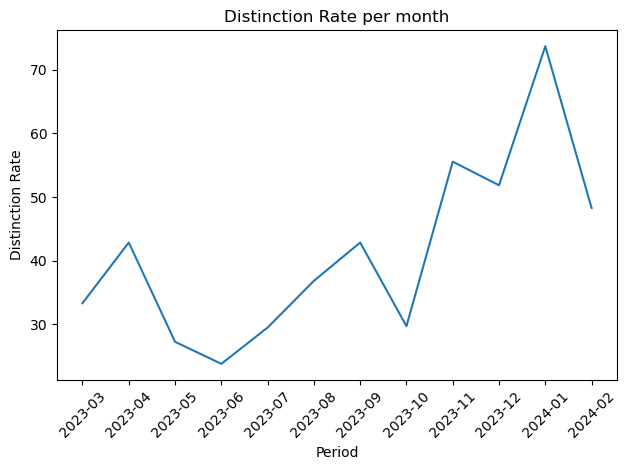

In [51]:
fig,ax = plt.subplots()

ax.plot(distinction_rate['period'].astype('str'),distinction_rate['dist_col']*100)
plt.xticks(rotation=45)


ax.set_title('Distinction Rate per month')
ax.set_xlabel('Period')
ax.set_ylabel('Distinction Rate')
plt.tight_layout()
plt.show()

In [55]:
distinction_rate_epao = df.groupby(['period',EPAO_COL])['dist_col'].mean().reset_index()
print(distinction_rate_epao)

     period  EPAO  dist_col
0   2023-03   AIM  0.000000
1   2023-03    AP  0.307692
2   2023-03   BCS  0.428571
3   2023-04   AIM  1.000000
4   2023-04    AP  0.500000
5   2023-04   BCS  0.285714
6   2023-05  A4PM  0.000000
7   2023-05   AIM  0.500000
8   2023-05    AP  0.363636
9   2023-05   BCS  0.125000
10  2023-06  A4PM  0.500000
11  2023-06   AIM  0.500000
12  2023-06    AP  0.125000
13  2023-06   BCS  0.222222
14  2023-07  A4PM  0.333333
15  2023-07   AIM  0.333333
16  2023-07    AP  0.500000
17  2023-07   BCS  0.100000
18  2023-08  A4PM  0.750000
19  2023-08   AIM  0.000000
20  2023-08    AP  0.500000
21  2023-08   BCS  0.142857
22  2023-09  A4PM  0.800000
23  2023-09   AIM  0.250000
24  2023-09    AP  0.625000
25  2023-09   BCS  0.181818
26  2023-10  A4PM  0.500000
27  2023-10   AIM  0.000000
28  2023-10    AP  0.562500
29  2023-10   BCS  0.055556
30  2023-11  A4PM  1.000000
31  2023-11   AIM  0.666667
32  2023-11    AP  0.600000
33  2023-11   BCS  0.166667
34  2023-12  A4PM  0

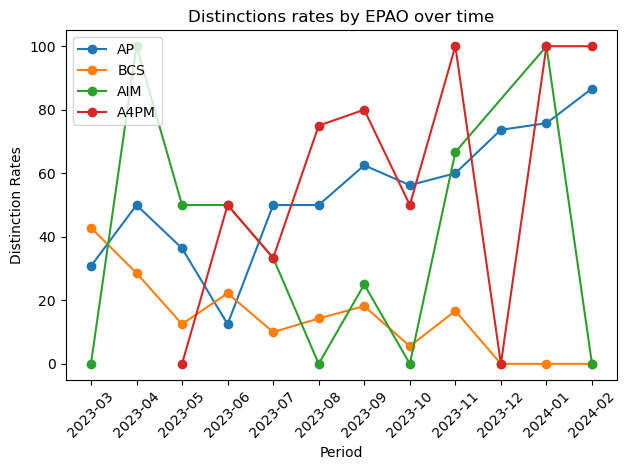

In [62]:
fig,ax = plt.subplots()

for epao in df[EPAO_COL].unique():
    subset = distinction_rate_epao[distinction_rate_epao[EPAO_COL] == epao]
    ax.plot(subset['period'].astype(str), subset['dist_col'] * 100, label=epao, marker='o')
ax.set_title('Distinctions rates by EPAO over time')
ax.set_xlabel('Period')
ax.set_ylabel('Distinction Rates')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Observations

There is an overall spike in Distinction completion rates towards the latter part of the dataset, on closer inspection with EPAO split out we see AP has an improved distinction rate across the period while BCS reduces. Although we can see some trends I don't believe time may have a massive impact on outcome over other features like level of course and assessment organisation

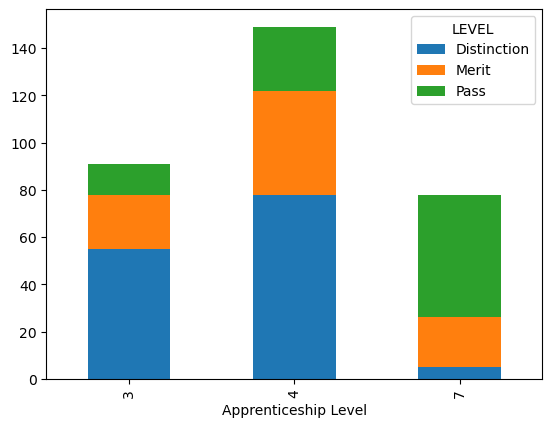

In [63]:
df_viz5 = pd.crosstab(index=df[LEVEL_COL],columns=(df[GRADE_COL]))

fig5, ax5= plt.subplots()
df_viz5.plot(kind='bar', stacked=True, ax=ax5)
ax5.legend(title='LEVEL')

### Observation

Level is massive indicator about who will achieve a distinction as lower level cohorts have a higher probability to achieve a distinction. Level 3 learners achieve distinctions at approximately 60%, compared to roughly 52% at Level 4 and just 6% at Level 7. This stark difference in grade distributions across levels confirms that a single model applied to the entire dataset would be dominated by Level effects. This reinforces the decision to build separate stratified models per level. Furthermore, since Level determines which EPAO a learner uses — with Level 7 exclusively assessed by BCS — stratifying by Level also helps untangle the confounding relationship between EPAO and grade outcomes identified earlier in this analysis.